<a href="https://colab.research.google.com/github/ItishreeJena/Ecommerce/blob/main/CNN_in_complex_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#first, lets download, im going to build horses or humans classifier  that will tell you if a given image contains a horse or a human, where the network is trained to recognize features that determine which is which. I'll have to do some processing of the data before i can train.
!wget \
  https://storage.googleapis.com/learning-datasets/horse-or-human.zip \
  -O /tmp/horse-or-human.zip

--2026-07-24 14:01:47--  https://storage.googleapis.com/learning-datasets/horse-or-human.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.101.207, 142.250.141.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149574867 (143M) [application/zip]
Saving to: ‘/tmp/horse-or-human.zip’

/tmp/horse-or-human 100%[===================>] 142.65M   111MB/s    in 1.3s    

2026-07-24 14:01:48 (111 MB/s) - ‘/tmp/horse-or-human.zip’ saved [149574867/149574867]



In [3]:
import os
import zipfile
local_zip = '/tmp/horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/horse-or-human')
zip_ref.close()

In [4]:
#use ImageDataGenerator to label and prepare the data
#Define each of those directories.

# Directory with our training horse pictures
train_horse_dir = os.path.join('/tmp/horse-or-human/horses')

# Directory with our training human pictures
train_human_dir = os.path.join('/tmp/horse-or-human/humans')

In [5]:
#Now, see what the filenames look like in the horses and humans training directories:
train_horse_names = os.listdir(train_horse_dir)
print(train_horse_names[:10])
train_human_names = os.listdir(train_human_dir)
print(train_human_names[:10])

['horse18-7.png', 'horse18-6.png', 'horse41-9.png', 'horse10-0.png', 'horse16-4.png', 'horse38-3.png', 'horse18-9.png', 'horse20-7.png', 'horse46-3.png', 'horse16-5.png']
['human17-09.png', 'human08-21.png', 'human06-26.png', 'human12-22.png', 'human14-28.png', 'human17-18.png', 'human13-29.png', 'human03-07.png', 'human07-08.png', 'human02-15.png']


In [6]:
#Find the total number of horse and human images in the directories:
print('total training horse images:', len(os.listdir(train_horse_dir)))
print('total training human images:', len(os.listdir(train_human_dir)))

total training horse images: 500
total training human images: 527


In [7]:
#EXPLORE THE DATA

#First, configure the matplot parameters:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

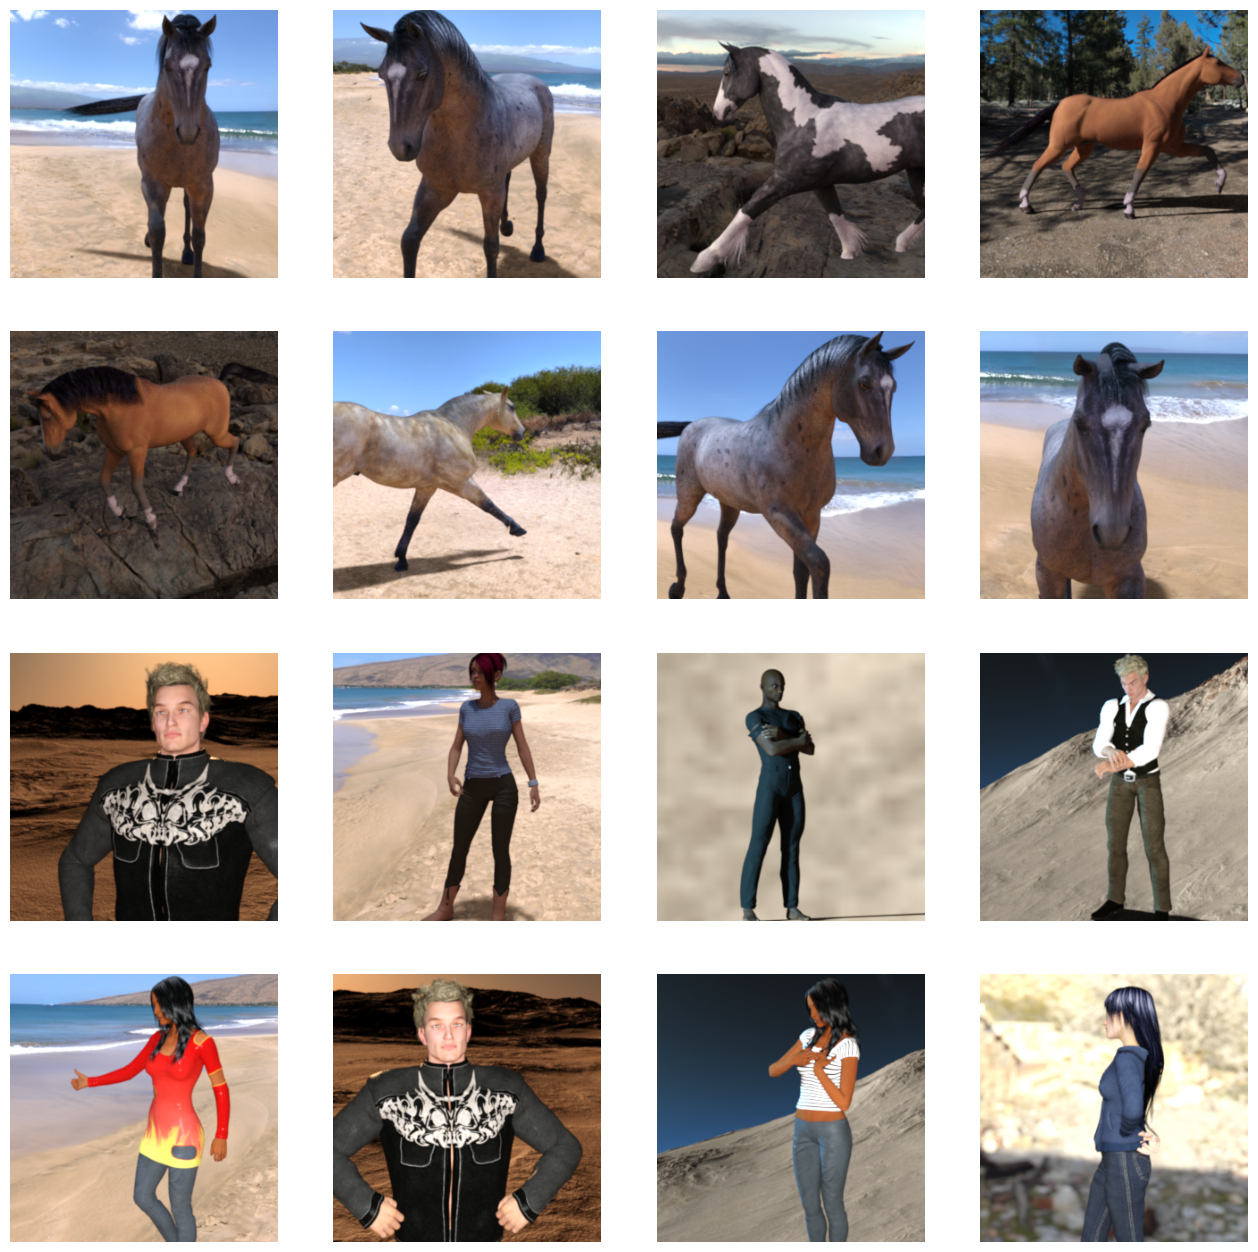

In [8]:
#Now, display a batch of eight horse pictures and eight human pictures. You can rerun the cell to see a fresh batch each time.
# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8
next_horse_pix = [os.path.join(train_horse_dir, fname)
                for fname in train_horse_names[pic_index-8:pic_index]]
next_human_pix = [os.path.join(train_human_dir, fname)
                for fname in train_human_names[pic_index-8:pic_index]]

for i, img_path in enumerate(next_horse_pix+next_human_pix):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()



**DEFINE THE MODE**

In [9]:
#Begin by importing TensorFlow
import tensorflow as tf

In [10]:
#Then, add convolutional layers and flatten the final result to feed into the densely connected layers. Finally, add the densely connected layers.
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 300x300 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fifth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('horses') and 1 for the other ('humans')
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary() #method call prints a summary of the network

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,097 (6.50 MB)

 Trainable params: 1,704,097 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILING THE MODEL
Next, configure the specifications for model training. Train your model with the binary_crossentropy loss because it's a binary classification problem and your final activation is a sigmoid. (For a refresher on loss metrics, see Descending into ML.) Use the rmsprop optimizer with a learning rate of 0.001. During training, monitor classification accuracy.

Note: In this case, using the RMSprop optimization algorithm is preferable to stochastic gradient descent (SGD) because RMSprop automates learning-rate tuning for you. (Other optimizers, such as Adam and Adagrad, also automatically adapt the learning rate during training and would work equally well here.)

In [12]:
# COMPILE THE MODEL
from tensorflow.keras.optimizers import RMSprop

model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=0.001),
    metrics=['acc']
)

In [13]:
#train the model from generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        '/tmp/horse-or-human/',  # This is the source directory for training images
        target_size=(300, 300),  # All images will be resized to 150x150
        batch_size=128,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

Found 1027 images belonging to 2 classes.


In [14]:
#do the training
history = model.fit(
      train_generator,
      steps_per_epoch=8,
      epochs=15,
      verbose=1)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 57s 7s/step - acc: 0.5406 - loss: 0.7567
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - acc: 0.5156 - loss: 0.6887
Epoch 3/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


8/8 ━━━━━━━━━━━━━━━━━━━━ 72s 6s/step - acc: 0.6452 - loss: 0.6547
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - acc: 0.7500 - loss: 0.5684
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - acc: 0.6563 - loss: 0.6696
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - acc: 0.8516 - loss: 0.4998
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step - acc: 0.8086 - loss: 0.4281
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.6667 - loss: 1.6576  
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - acc: 0.7831 - loss: 0.5146
Epoch 10/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - acc: 0.8594 - loss: 0.3707
Epoch 11/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 76s 6s/step - acc: 0.8554 - loss: 0.3633
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - acc: 0.9297 - loss: 0.2083
Epoch 13/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 81s 7s/step - acc: 0.9805 - loss: 0.0857
Epoch 14/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 1.0000 - loss: 0.0437  
Epoch 15/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 6s/step - acc: 0.8320 - loss: 0.5612


In [17]:
#testing the model
import numpy as np
from google.colab import files
from keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():

  # predicting images
  path = '/content/' + fn
  img = image.load_img(path, target_size=(300, 300))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)

  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes[0])
  if classes[0]>0.5:
    print(fn + " is a human")
  else:
    print(fn + " is a horse")

Saving c9213173d9f3d83c_856.jpeg to c9213173d9f3d83c_856.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[0.]
c9213173d9f3d83c_856.jpeg is a horse


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


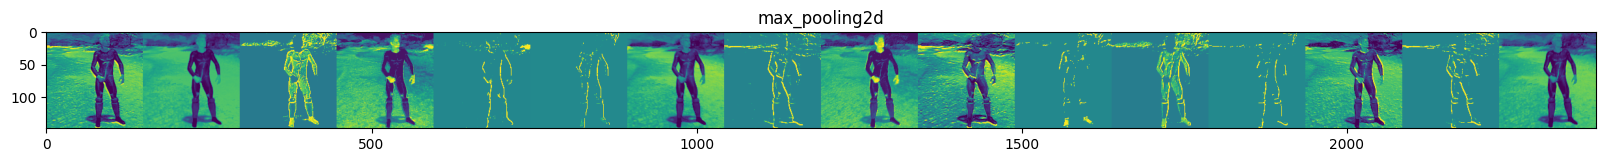

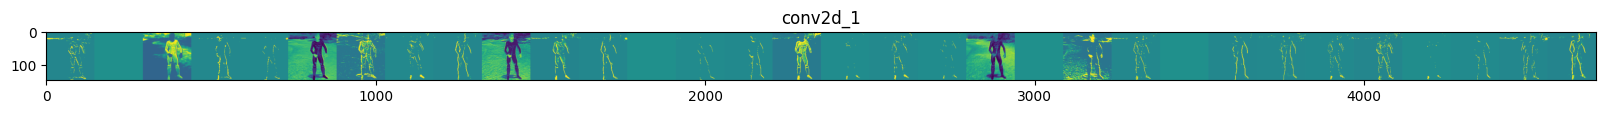

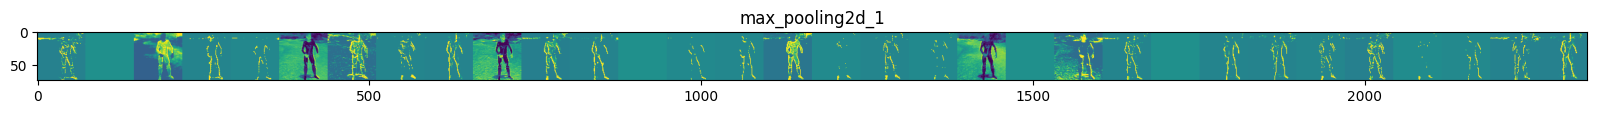

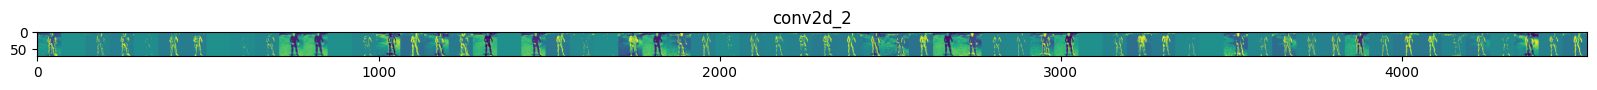

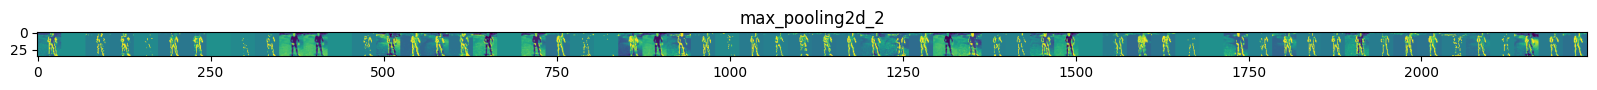

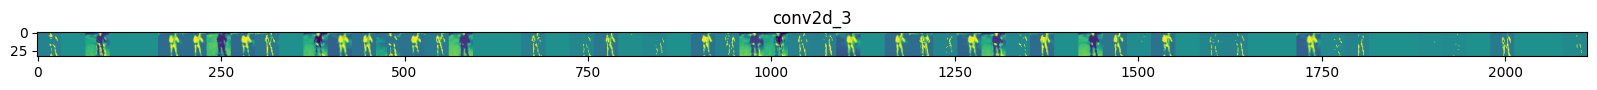

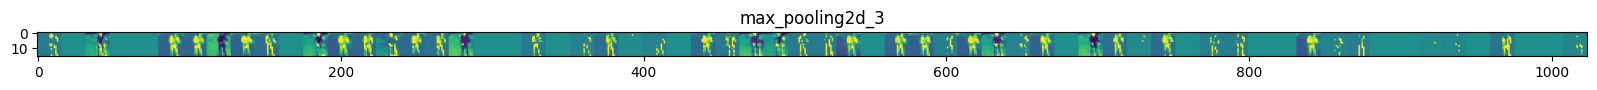

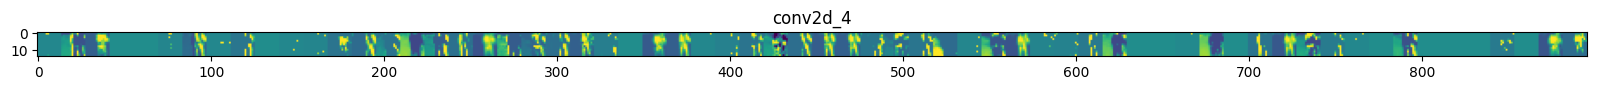

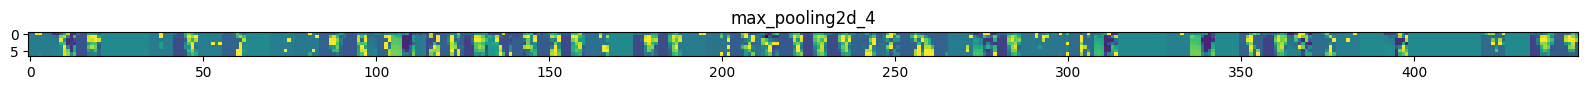

In [19]:
# visualizing intermediate representations
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# 1. Define symbolic input matching your image shape (300, 300, 3)
inputs = tf.keras.Input(shape=(300, 300, 3))

# 2. Pass the input sequentially through all layers to capture outputs
layer_outputs = []
x_in = inputs
for layer in model.layers:
    x_in = layer(x_in)
    layer_outputs.append(x_in)

# 3. Create the visualization model (exclude the input layer output itself)
visualization_model = tf.keras.models.Model(inputs=inputs, outputs=layer_outputs[1:])

# 4. Prepare a random input image from the training set
horse_img_files = [os.path.join(train_horse_dir, f) for f in train_horse_names]
human_img_files = [os.path.join(train_human_dir, f) for f in train_human_names]
img_path = random.choice(horse_img_files + human_img_files)

img = load_img(img_path, target_size=(300, 300))  # PIL image
x = img_to_array(img)                             # Numpy array with shape (300, 300, 3)
x = x.reshape((1,) + x.shape)                     # Numpy array with shape (1, 300, 300, 3)

# Rescale by 1/255
x /= 255

# 5. Get intermediate feature maps
successive_feature_maps = visualization_model.predict(x)

# Layer names starting from the second layer
layer_names = [layer.name for layer in model.layers[1:]]

# 6. Display representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:
        n_features = feature_map.shape[-1]  # number of features in feature map
        size = feature_map.shape[1]

        display_grid = np.zeros((size, size * n_features))
        for i in range(n_features):
            f = feature_map[0, :, :, i]
            f -= f.mean()
            if f.std() > 0:
                f /= f.std()
            f *= 64
            f += 128
            f = np.clip(f, 0, 255).astype('uint8')
            display_grid[:, i * size : (i + 1) * size] = f

        scale = 20. / n_features
        plt.figure(figsize=(scale * n_features, scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

plt.show()